In [1]:
%reload_ext autoreload
%autoreload 2


In [2]:

import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.98"

import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

plt.style.use("../dmri/utils/pyloric_black.mplstyle")

# Ignore font warnings from matplotlib
import warnings
warnings.filterwarnings("ignore")
# Ignore all font-related warnings from matplotlib
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")
# Specifically suppress font family warnings
warnings.filterwarnings("ignore", message="findfont: Generic family.*Arial")


Duplicate key in file '../dmri/utils/pyloric_black.mplstyle', line 65 ('savefig.facecolor    : black       # Ensures black background when saving')


In [3]:
from dmri.train.utils import load_cfg, load_checkpoint

checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/new_multishell_ball3stick_simformer6_v_pred")
graphdef, params, static, state = nnx.split(model, nnx.Param, nnx.Intermediate, ...)
params = checkpoint["params_ema"]

model = nnx.merge(graphdef, params, static, state)
model.eval()

In [4]:
sim_type = model.tokenizer.simulator

In [5]:
def loglikelihood(theta, mask, acq, x):
    simulator = sim_type.from_theta(theta, model_mask=mask)
    ll = simulator.log_likelihood(acq, x)
    return ll

In [6]:
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti

import numpy as np

data, affine = load_nifti("data/data.nii.gz")
brain_mask, _ = load_nifti("data/nodif_brain_mask.nii.gz")
_bvals, bvecs = read_bvals_bvecs("data/bvals", "data/bvecs")

# Round bvals to nearest (0, 1000, 2000)
bvals_rounded = np.round(_bvals / 1000) * 1000
bvals = np.clip(bvals_rounded, 0, 2000)
b0_mask = bvals == 0

S0 = np.mean(data[..., b0_mask], -1)

data_norm = data / S0[..., None]
data_norm = np.where(brain_mask[...,None], data_norm, 0.)
data_norm = np.where(np.isnan(data_norm), 0., data_norm)
S0 = np.where(brain_mask, S0, 0.)

FileNotFoundError: No such file or no access: 'data/data.nii.gz'

In [8]:
idx = np.argsort(bvals)

bvals = bvals[idx]
bvecs = bvecs[idx]
data_norm = data_norm[...,idx]


In [9]:
full_data_flat = data_norm.reshape(-1, data_norm.shape[-1])
brain_mask_flat = brain_mask.reshape(-1)

full_data_flat_in_brain = full_data_flat[brain_mask_flat.astype(np.bool),:]

In [10]:
full_data_flat_in_brain = np.nan_to_num(full_data_flat_in_brain, nan=0, posinf=0, neginf=0)

In [11]:
exclude_outliers = np.quantile(full_data_flat_in_brain, 0.999)
full_data_flat_in_brain = np.clip(full_data_flat_in_brain, 0, exclude_outliers)

In [12]:
acq = acquisition_scheme(np.array(bvals), np.array(bvecs))

# Model selection prior


In [13]:
ps = np.linspace(0,1,100)

In [14]:

def prior_log_prob(model_mask, p):
    N = model_mask.shape[0]
    log_probs = []

    for i in range(N-1):
        if model_mask[i] != 1:
            # If the forced index isn't 1, this component gives zero prob.
            log_probs.append(-jnp.inf)
        else:
            mask_except_i = jnp.concatenate([model_mask[:i], model_mask[i+1:]])
            logpmf_except_i = jax.scipy.stats.bernoulli.logpmf(mask_except_i, p)
            log_prob_i = jnp.sum(logpmf_except_i)
            log_probs.append(log_prob_i)

    return jax.scipy.special.logsumexp(jnp.array(log_probs)) - jnp.log(N)


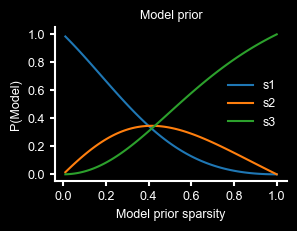

In [15]:
prior_probs1 = [prior_log_prob(jnp.array([True, True, False, False, True]), p) for p in ps]
prior_probs2 = [prior_log_prob(jnp.array([True, True, True, False, True]), p) for p in ps]
prior_probs3 = [prior_log_prob(jnp.array([True, True, True, True, True]), p) for p in ps]

prior_probs = np.stack([prior_probs1, prior_probs2, prior_probs3], axis=-1)
prior_probs = jax.nn.softmax(prior_probs, axis=-1)

fig = plt.figure(figsize=(3,2))
_ = plt.plot(ps, prior_probs[:,0], color=(0.122, 0.467, 0.706))
_ = plt.plot(ps, prior_probs[:,1], color=(1.0, 0.498, 0.055))
_ = plt.plot(ps, prior_probs[:,2], color=(0.173, 0.627, 0.173))

plt.xlabel("Model prior sparsity")
plt.ylabel("P(Model)")
plt.legend([plt.Line2D([0], [0], color=(0.122, 0.467, 0.706), label='s1'),
           plt.Line2D([0], [0], color=(1.0, 0.498, 0.055), label='s2'),
           plt.Line2D([0], [0], color=(0.173, 0.627, 0.173), label='s3')],
          ['s1', 's2', 's3'])
plt.title("Model prior")
plt.savefig("figures_model_sel/model_prior.png")

In [16]:
#from functools import partial
#x_o = full_data_flat_in_brain[21_800]
#x_o = full_data_flat_in_brain[24_800]
# x_o = full_data_flat_in_brain[70_000]
#x_o = full_data_flat_in_brain[27_800]
#x_o = full_data_flat_in_brain[30_800]
#x_o = full_data_flat_in_brain[100_000]
#x_o = full_data_flat_in_brain[200_000]
#model_mask = jnp.ones(5, dtype=jnp.bool)
# model_mask = jnp.array([True, True, True, False, True], dtype=jnp.bool)


# Model selection on isotropic signal



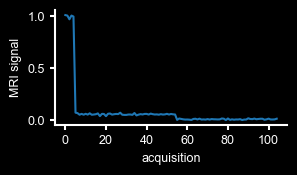

In [17]:
x_o = full_data_flat_in_brain[70_000]
plt.figure(figsize=(3,1.5))
plt.plot(x_o)
plt.ylabel("MRI signal")
plt.xlabel("acquisition")

plt.savefig("figures_model_sel/signal_isotropic.png")


In [18]:
from functools import partial
@jax.jit
def estimate_marginal_likelihood_naive(rng,model_mask, x_o):
    n_samples = 100_000_000
    n_batches = 200

    def scan_body(carry, rng):
        thetas = jax.random.normal(rng, (n_samples, 12))
        ll = jax.vmap(partial(loglikelihood, mask=model_mask, acq=acq, x=x_o))(thetas)
        # Accumulate log sum exp in the loop
        new_carry = jax.scipy.special.logsumexp(jnp.array([carry, jax.scipy.special.logsumexp(ll)]))
        return new_carry, None

    initial_carry = -jnp.inf  # Initialize with -inf for log sum exp
    final_sum, _ = jax.lax.scan(scan_body, initial_carry, jax.random.split(rng, n_batches))

    N = n_samples * n_batches
    return final_sum - jnp.log(N)

@jax.jit
def estimate_marginal_likelihood(rng,model_mask, x_o):
    n_samples = 20_000
    thetas, log_probs = jax.vmap(partial(model.sample_and_log_prob_theta, num_steps=128, max_noise=80), in_axes=(0,None,None,None,None))(jax.random.split(rng, n_samples), acq.bvals, acq.bvecs, x_o, model_mask)
    prior_probs = jax.scipy.stats.norm.logpdf(thetas, 0, 1).sum(-1)
    logweights = prior_probs - log_probs
    true_ll = jax.vmap(partial(loglikelihood, mask=model_mask, acq=acq, x=x_o))(thetas)
    importance_weighted_ll = logweights + true_ll
    return jax.scipy.special.logsumexp(importance_weighted_ll) - jnp.log(n_samples)


def estimate_true_mask_posterior(model_mask, ll,p):
    prior = prior_log_prob(model_mask, p)
    return ll + prior


In [19]:
ll1s = [estimate_marginal_likelihood(jax.random.key(i), jnp.array([True, True, False, False, True]), x_o) for i in range(3)]
ll2s = [estimate_marginal_likelihood(jax.random.key(i), jnp.array([True, True, True, False, True]), x_o) for i in range(3)]
ll3s = [estimate_marginal_likelihood(jax.random.key(i), jnp.array([True, True, True, True, True]), x_o) for i in range(3)]


In [69]:
ll1s

[Array(335.832, dtype=float32),
 Array(335.794, dtype=float32),
 Array(335.82, dtype=float32)]

In [21]:
ps_mc = []
ps_est = []
for p_prior in ps:
    # True posterior
    # First ll estimate
    ps_true_all = []
    for i in range(len(ll1s)):
        p_ball_stick1 = estimate_true_mask_posterior(jnp.array([True, True, False, False, True]), ll1s[i], p_prior)
        p_ball_stick1_stick2 = estimate_true_mask_posterior(jnp.array([True, True, True, False, True]), ll2s[i], p_prior)
        p_ball_s123 = estimate_true_mask_posterior(jnp.array([True, True, True, True, True]), ll3s[i], p_prior)

        ps_true = jnp.stack([p_ball_stick1, p_ball_stick1_stick2, p_ball_s123], axis=-1)
        ps_true = jax.nn.softmax(ps_true, axis=-1)
        ps_true_all.append(ps_true)

    ps_mc.append(ps_true_all)

    # Model estimate
    p_ball_stick1_est = model.log_prob_mask(jnp.array([True, True, False, False, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))
    p_ball_stick1_stick2_est = model.log_prob_mask(jnp.array([True, True, True, False, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))
    p_ball_s123_est = model.log_prob_mask(jnp.array([True, True, True, True, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))

    ps_model = jnp.stack([p_ball_stick1_est, p_ball_stick1_stick2_est, p_ball_s123_est], axis=-1)
    ps_model = jax.nn.softmax(ps_model, axis=-1)
    ps_est.append(ps_model)


In [22]:
ps_mc_mean = [np.mean(ps_mc[i], axis=0) for i in range(len(ps_mc))]
ps_mc_q05 = [np.quantile(ps_mc[i], 0.05, axis=0) for i in range(len(ps_mc))]
ps_mc_q95 = [np.quantile(ps_mc[i], 0.95, axis=0) for i in range(len(ps_mc))]

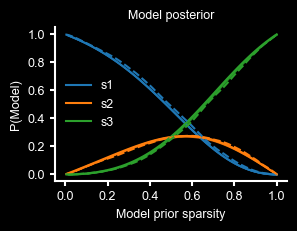

In [23]:

fig = plt.figure(figsize=(3,2))
_ = plt.plot(ps, [p[0] for p in ps_mc_mean], color=(0.122, 0.467, 0.706))
_ = plt.plot(ps, [p[1] for p in ps_mc_mean], color=(1.0, 0.498, 0.055))
_ = plt.plot(ps, [p[2] for p in ps_mc_mean], color=(0.173, 0.627, 0.173))

_ = plt.fill_between(ps, [p[0] for p in ps_mc_q05], [p[0] for p in ps_mc_q95], color=(0.122, 0.467, 0.706), alpha=0.8)
_ = plt.fill_between(ps, [p[1] for p in ps_mc_q05], [p[1] for p in ps_mc_q95], color=(1.0, 0.498, 0.055), alpha=0.8)
_ = plt.fill_between(ps, [p[2] for p in ps_mc_q05], [p[2] for p in ps_mc_q95], color=(0.173, 0.627, 0.173), alpha=0.8)

_ = plt.plot(ps, [p[0] for p in ps_est], color=(0.122, 0.467, 0.706), linestyle="--")
_ = plt.plot(ps, [p[1] for p in ps_est], color=(1.0, 0.498, 0.055), linestyle="--")
_ = plt.plot(ps, [p[2] for p in ps_est], color=(0.173, 0.627, 0.173), linestyle="--")

plt.xlabel("Model prior sparsity")
plt.ylabel("P(Model)")
plt.legend([plt.Line2D([0], [0], color=(0.122, 0.467, 0.706), label='s1'),
           plt.Line2D([0], [0], color=(1.0, 0.498, 0.055), label='s2'),
           plt.Line2D([0], [0], color=(0.173, 0.627, 0.173), label='s3')],
          ['s1', 's2', 's3'])
plt.title("Model posterior")
plt.savefig("figures_model_sel/model_posterior_isotropic.png")

# Model selection non-isotropic

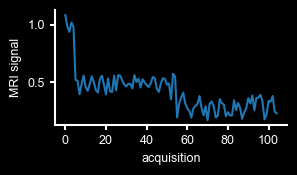

In [82]:
x_o = full_data_flat_in_brain[21_800]
plt.figure(figsize=(3,1.5))
plt.plot(x_o)
plt.ylabel("MRI signal")
plt.xlabel("acquisition")
plt.savefig("figures_model_sel/signal_non_isotropic.png")

In [83]:
ll1s_noniso = [estimate_marginal_likelihood(jax.random.key(i), jnp.array([True, True, False, False, True]), x_o) for i in range(5)]
ll2s_noniso = [estimate_marginal_likelihood(jax.random.key(i), jnp.array([True, True, True, False, True]), x_o) for i in range(5)]
ll3s_noniso = [estimate_marginal_likelihood(jax.random.key(i), jnp.array([True, True, True, True, True]), x_o) for i in range(5)]


In [84]:
ll1s_noniso

[Array(216.312, dtype=float32),
 Array(216.287, dtype=float32),
 Array(216.294, dtype=float32),
 Array(216.285, dtype=float32),
 Array(216.313, dtype=float32)]

In [85]:
ll3s_noniso

[Array(216.767, dtype=float32),
 Array(216.965, dtype=float32),
 Array(218.063, dtype=float32),
 Array(216.714, dtype=float32),
 Array(216.742, dtype=float32)]

In [86]:
ps_mc = []
ps_est = []
for p_prior in ps:
    # True posterior
    # First ll estimate
    ps_true_all = []
    for i in range(len(ll1s)):
        p_ball_stick1 = estimate_true_mask_posterior(jnp.array([True, True, False, False, True]), ll1s_noniso[i], p_prior)
        p_ball_stick1_stick2 = estimate_true_mask_posterior(jnp.array([True, True, True, False, True]), ll2s_noniso[i], p_prior)
        p_ball_s123 = estimate_true_mask_posterior(jnp.array([True, True, True, True, True]), ll3s_noniso[i], p_prior)

        ps_true = jnp.stack([p_ball_stick1, p_ball_stick1_stick2, p_ball_s123], axis=-1)
        ps_true = jax.nn.softmax(ps_true, axis=-1)
        ps_true_all.append(ps_true)

    ps_mc.append(ps_true_all)

    # Model estimate
    p_ball_stick1_est = model.log_prob_mask(jnp.array([True, True, False, False, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))
    p_ball_stick1_stick2_est = model.log_prob_mask(jnp.array([True, True, True, False, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))
    p_ball_s123_est = model.log_prob_mask(jnp.array([True, True, True, True, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))

    ps_model = jnp.stack([p_ball_stick1_est, p_ball_stick1_stick2_est, p_ball_s123_est], axis=-1)
    ps_model = jax.nn.softmax(ps_model, axis=-1)
    ps_est.append(ps_model)


In [87]:
ps_mc_mean = [np.mean(ps_mc[i], axis=0) for i in range(len(ps_mc))]
ps_mc_q05 = [np.quantile(ps_mc[i], 0.05, axis=0) for i in range(len(ps_mc))]
ps_mc_q95 = [np.quantile(ps_mc[i], 0.95, axis=0) for i in range(len(ps_mc))]

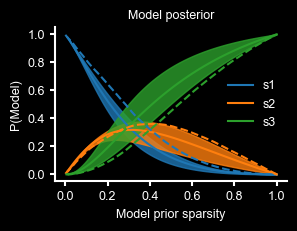

: 

In [88]:

fig = plt.figure(figsize=(3,2))
_ = plt.plot(ps, [p[0] for p in ps_mc_mean], color=(0.122, 0.467, 0.706))
_ = plt.plot(ps, [p[1] for p in ps_mc_mean], color=(1.0, 0.498, 0.055))
_ = plt.plot(ps, [p[2] for p in ps_mc_mean], color=(0.173, 0.627, 0.173))

_ = plt.fill_between(ps, [p[0] for p in ps_mc_q05], [p[0] for p in ps_mc_q95], color=(0.122, 0.467, 0.706), alpha=0.8)
_ = plt.fill_between(ps, [p[1] for p in ps_mc_q05], [p[1] for p in ps_mc_q95], color=(1.0, 0.498, 0.055), alpha=0.8)
_ = plt.fill_between(ps, [p[2] for p in ps_mc_q05], [p[2] for p in ps_mc_q95], color=(0.173, 0.627, 0.173), alpha=0.8)

_ = plt.plot(ps, [p[0] for p in ps_est], color=(0.122, 0.467, 0.706), linestyle="--")
_ = plt.plot(ps, [p[1] for p in ps_est], color=(1.0, 0.498, 0.055), linestyle="--")
_ = plt.plot(ps, [p[2] for p in ps_est], color=(0.173, 0.627, 0.173), linestyle="--")

plt.xlabel("Model prior sparsity")
plt.ylabel("P(Model)")
plt.legend([plt.Line2D([0], [0], color=(0.122, 0.467, 0.706), label='s1'),
           plt.Line2D([0], [0], color=(1.0, 0.498, 0.055), label='s2'),
           plt.Line2D([0], [0], color=(0.173, 0.627, 0.173), label='s3')],
          ['s1', 's2', 's3'])
plt.title("Model posterior")
plt.savefig("figures_model_sel/model_posterior_non_isotropic.png")

# Model selection strongly non-isotropic

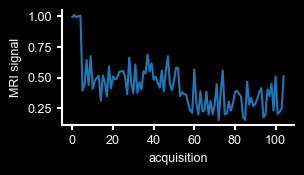

In [30]:
x_o = full_data_flat_in_brain[200_000]
plt.figure(figsize=(3,1.5))
plt.plot(x_o)
plt.ylabel("MRI signal")
plt.xlabel("acquisition")
plt.savefig("figures_model_sel/signal_strongly_non_isotropic.png")


In [31]:
ll1s_noniso_strong = [estimate_marginal_likelihood(jax.random.key(i), jnp.array([True, True, False, False, True]), x_o) for i in range(3)]
ll2s_noniso_strong = [estimate_marginal_likelihood(jax.random.key(i), jnp.array([True, True, True, False, True]), x_o) for i in range(3)]
ll3s_noniso_strong = [estimate_marginal_likelihood(jax.random.key(i), jnp.array([True, True, True, True, True]), x_o) for i in range(3)]

ll1s_noniso_strong


[Array(93.301, dtype=float32),
 Array(76.002, dtype=float32),
 Array(77.482, dtype=float32)]

In [32]:
ps_mc = []
ps_est = []
for p_prior in ps:
    # True posterior
    # First ll estimate
    ps_true_all = []
    for i in range(len(ll1s)):
        p_ball_stick1 = estimate_true_mask_posterior(jnp.array([True, True, False, False, True]), ll1s_noniso_strong[i], p_prior)
        p_ball_stick1_stick2 = estimate_true_mask_posterior(jnp.array([True, True, True, False, True]), ll2s_noniso_strong[i], p_prior)
        p_ball_s123 = estimate_true_mask_posterior(jnp.array([True, True, True, True, True]), ll3s_noniso_strong[i], p_prior)

        ps_true = jnp.stack([p_ball_stick1, p_ball_stick1_stick2, p_ball_s123], axis=-1)
        ps_true = jax.nn.softmax(ps_true, axis=-1)
        ps_true_all.append(ps_true)

    ps_mc.append(ps_true_all)

    # Model estimate
    p_ball_stick1_est = model.log_prob_mask(jnp.array([True, True, False, False, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))
    p_ball_stick1_stick2_est = model.log_prob_mask(jnp.array([True, True, True, False, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))
    p_ball_s123_est = model.log_prob_mask(jnp.array([True, True, True, True, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))

    ps_model = jnp.stack([p_ball_stick1_est, p_ball_stick1_stick2_est, p_ball_s123_est], axis=-1)
    ps_model = jax.nn.softmax(ps_model, axis=-1)
    ps_est.append(ps_model)


In [33]:
ps_mc_mean = [np.mean(ps_mc[i], axis=0) for i in range(len(ps_mc))]
ps_mc_q05 = [np.quantile(ps_mc[i], 0.05, axis=0) for i in range(len(ps_mc))]
ps_mc_q95 = [np.quantile(ps_mc[i], 0.95, axis=0) for i in range(len(ps_mc))]

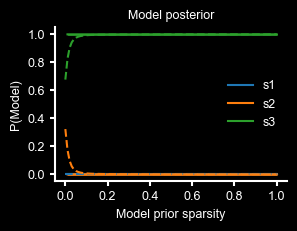

In [34]:

fig = plt.figure(figsize=(3,2))
_ = plt.plot(ps, [p[0] for p in ps_mc_mean], color=(0.122, 0.467, 0.706))
_ = plt.plot(ps, [p[1] for p in ps_mc_mean], color=(1.0, 0.498, 0.055))
_ = plt.plot(ps, [p[2] for p in ps_mc_mean], color=(0.173, 0.627, 0.173))

_ = plt.fill_between(ps, [p[0] for p in ps_mc_q05], [p[0] for p in ps_mc_q95], color=(0.122, 0.467, 0.706), alpha=0.8)
_ = plt.fill_between(ps, [p[1] for p in ps_mc_q05], [p[1] for p in ps_mc_q95], color=(1.0, 0.498, 0.055), alpha=0.8)
_ = plt.fill_between(ps, [p[2] for p in ps_mc_q05], [p[2] for p in ps_mc_q95], color=(0.173, 0.627, 0.173), alpha=0.8)

_ = plt.plot(ps, [p[0] for p in ps_est], color=(0.122, 0.467, 0.706), linestyle="--")
_ = plt.plot(ps, [p[1] for p in ps_est], color=(1.0, 0.498, 0.055), linestyle="--")
_ = plt.plot(ps, [p[2] for p in ps_est], color=(0.173, 0.627, 0.173), linestyle="--")

plt.xlabel("Model prior sparsity")
plt.ylabel("P(Model)")
plt.legend([plt.Line2D([0], [0], color=(0.122, 0.467, 0.706), label='s1'),
           plt.Line2D([0], [0], color=(1.0, 0.498, 0.055), label='s2'),
           plt.Line2D([0], [0], color=(0.173, 0.627, 0.173), label='s3')],
          ['s1', 's2', 's3'])
plt.title("Model posterior")
plt.savefig("figures_model_sel/model_posterior_strongly_non_isotropic.png")

In [ ]:
# Full model selection

In [45]:
# Sample masks whole brain
p_prior = 0.1

def sample_mask_per_x(key, x):
    log_probs_bs1 = model.log_prob_mask(jnp.array([True, True, False, False, True]), acq.bvals, acq.bvecs, x, jnp.array([p_prior]))
    log_probs_bs12 = model.log_prob_mask(jnp.array([True, True, True, False, True]), acq.bvals, acq.bvecs, x, jnp.array([p_prior]))
    log_probs_bs123 = model.log_prob_mask(jnp.array([True, True, True, True, True]), acq.bvals, acq.bvecs, x, jnp.array([p_prior]))
    log_probs = jnp.stack([log_probs_bs1, log_probs_bs12, log_probs_bs123], axis=-1)
    return log_probs

sample_mask_per_x = jax.jit(jax.vmap(sample_mask_per_x, in_axes=(0,0)))


batch_size = 10_000
key = jax.random.key(0)
probs_brain_01 = []
key, subkey = jax.random.split(key)
for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
    print("Batch", batch_start)
    subkey, subkey_ = jax.random.split(subkey)
    batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
    batch_data = full_data_flat_in_brain[batch_start:batch_end]
    batch_keys = jax.random.split(subkey_, batch_data.shape[0])
    batch_masks = sample_mask_per_x(batch_keys, batch_data)
    batch_masks = np.array(batch_masks)
    probs_brain_01.append(batch_masks)
probs_brain_01 = np.concatenate(probs_brain_01, axis=0)


Batch 0
Batch 10000
Batch 20000
Batch 30000
Batch 40000
Batch 50000
Batch 60000
Batch 70000
Batch 80000
Batch 90000
Batch 100000
Batch 110000
Batch 120000
Batch 130000
Batch 140000
Batch 150000
Batch 160000
Batch 170000
Batch 180000
Batch 190000
Batch 200000
Batch 210000
Batch 220000


In [46]:
full_probs01_in_brain = np.zeros((data_norm.shape[:-1]) + (3,))
full_probs01_in_brain[brain_mask.astype(bool), :] = probs_brain_01

# Sample masks whole brain

In [50]:
from dmri.utils.viz import orthoview_ultracompact
model_selected01 = np.argmax(full_probs01_in_brain, axis=-1)


In [55]:
fig = orthoview_ultracompact(model_selected01)
fig.write_html("figures_model_sel/model_selected01.html")

In [53]:
# Sample masks whole brain
p_prior = 0.4

def sample_mask_per_x(key, x):
    log_probs_bs1 = model.log_prob_mask(jnp.array([True, True, False, False, True]), acq.bvals, acq.bvecs, x, jnp.array([p_prior]))
    log_probs_bs12 = model.log_prob_mask(jnp.array([True, True, True, False, True]), acq.bvals, acq.bvecs, x, jnp.array([p_prior]))
    log_probs_bs123 = model.log_prob_mask(jnp.array([True, True, True, True, True]), acq.bvals, acq.bvecs, x, jnp.array([p_prior]))
    log_probs = jnp.stack([log_probs_bs1, log_probs_bs12, log_probs_bs123], axis=-1)
    return log_probs
sample_mask_per_x = jax.jit(jax.vmap(sample_mask_per_x, in_axes=(0,0)))


batch_size = 10_000
key = jax.random.key(0)
probs_brain_04 = []
key, subkey = jax.random.split(key)
for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
    print("Batch", batch_start)
    subkey, subkey_ = jax.random.split(subkey)
    batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
    batch_data = full_data_flat_in_brain[batch_start:batch_end]
    batch_keys = jax.random.split(subkey_, batch_data.shape[0])
    batch_masks = sample_mask_per_x(batch_keys, batch_data)
    batch_masks = np.array(batch_masks)
    probs_brain_04.append(batch_masks)
probs_brain_04 = np.concatenate(probs_brain_04, axis=0)


Batch 0
Batch 10000
Batch 20000
Batch 30000
Batch 40000
Batch 50000
Batch 60000
Batch 70000
Batch 80000
Batch 90000
Batch 100000
Batch 110000
Batch 120000
Batch 130000
Batch 140000
Batch 150000
Batch 160000
Batch 170000
Batch 180000
Batch 190000
Batch 200000
Batch 210000
Batch 220000


In [56]:
full_probs04_in_brain = np.zeros((data_norm.shape[:-1]) + (3,))
full_probs04_in_brain[brain_mask.astype(bool), :] = probs_brain_04

# Sample masks whole brain
model_selected04 = np.argmax(full_probs04_in_brain, axis=-1)

fig = orthoview_ultracompact(model_selected04)
fig.write_html("figures_model_sel/model_selected04.html")

In [58]:
# Sample masks whole brain
p_prior = 0.3

def sample_mask_per_x(key, x):
    log_probs_bs1 = model.log_prob_mask(jnp.array([True, True, False, False, True]), acq.bvals, acq.bvecs, x, jnp.array([p_prior]))
    log_probs_bs12 = model.log_prob_mask(jnp.array([True, True, True, False, True]), acq.bvals, acq.bvecs, x, jnp.array([p_prior]))
    log_probs_bs123 = model.log_prob_mask(jnp.array([True, True, True, True, True]), acq.bvals, acq.bvecs, x, jnp.array([p_prior]))
    log_probs = jnp.stack([log_probs_bs1, log_probs_bs12, log_probs_bs123], axis=-1)
    return log_probs

sample_mask_per_x = jax.jit(jax.vmap(sample_mask_per_x, in_axes=(0,0)))


batch_size = 10_000
key = jax.random.key(0)
probs_brain_03 = []
key, subkey = jax.random.split(key)
for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
    print("Batch", batch_start)
    subkey, subkey_ = jax.random.split(subkey)
    batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
    batch_data = full_data_flat_in_brain[batch_start:batch_end]
    batch_keys = jax.random.split(subkey_, batch_data.shape[0])
    batch_masks = sample_mask_per_x(batch_keys, batch_data)
    batch_masks = np.array(batch_masks)
    probs_brain_03.append(batch_masks)
probs_brain_03 = np.concatenate(probs_brain_03, axis=0)

full_probs03_in_brain = np.zeros((data_norm.shape[:-1]) + (3,))
full_probs03_in_brain[brain_mask.astype(bool), :] = probs_brain_03

model_selected03 = np.argmax(full_probs03_in_brain, axis=-1)


Batch 0
Batch 10000
Batch 20000
Batch 30000
Batch 40000
Batch 50000
Batch 60000
Batch 70000
Batch 80000
Batch 90000
Batch 100000
Batch 110000
Batch 120000
Batch 130000
Batch 140000
Batch 150000
Batch 160000
Batch 170000
Batch 180000
Batch 190000
Batch 200000
Batch 210000
Batch 220000


In [60]:
fig = orthoview_ultracompact(model_selected03)
fig.write_html("figures_model_sel/model_selected03.html")